# 01 - Bag of Words (BoW)

Model Evaluation Lab
---

In the previous notebook, we learned that Rule-Based Systems require manually written rules and struggle with complex language.

In this notebook, we will learn the first Machine Learning approach for NLP:
Bag of Words.

## 📜 History

Rule-Based Systems worked well for small tasks, but they had a major limitation:

Every new rule had to be written by humans.

As datasets became larger, writing thousands of rules became impossible.

Researchers started asking:

"Can a computer learn patterns directly from text instead of relying on manually written rules?"

This led to one of the earliest text representation techniques:

Bag of Words (BoW).

Instead of writing rules, BoW converts text into numbers that Machine Learning algorithms can understand.

## ❌ Why Rule-Based Systems Were Not Enough

Rule-Based Systems have several limitations:

- Every rule must be written manually.
- Difficult to maintain.
- Cannot understand new words.
- Cannot learn from data.
- Cannot improve automatically.

Machine Learning requires numbers, not text.

Therefore, we need a way to convert text into numerical features.

Bag of Words solves this problem.

## 💡 Core Idea

Bag of Words converts a sentence into a vector of word counts.

Example:

Sentence:

I love AI

Vocabulary:

[I, love, AI]

Vector:

[1,1,1]

Each value represents how many times a word appears.

## 🧠 Example

Sentence 1:

I love AI

Sentence 2:

I love Machine Learning

Vocabulary

I
love
AI
Machine
Learning

Now count each word.

# Build BoW Manually

In [3]:
sentences = [
    "I love AI",
    "I love Machine Learning"
]

# Build vocabulary manually
vocabulary = sorted(set(" ".join(sentences).split()))

print("Vocabulary:")
print(vocabulary)

Vocabulary:
['AI', 'I', 'Learning', 'Machine', 'love']


Convert Sentence into Vector

In [4]:
def sentence_to_vector(sentence, vocabulary):
    words = sentence.split()

    vector = []

    for word in vocabulary:
        vector.append(words.count(word))

    return vector


for sentence in sentences:
    print(sentence)
    print(sentence_to_vector(sentence, vocabulary))
    print()

I love AI
[1, 1, 0, 0, 1]

I love Machine Learning
[0, 1, 1, 1, 1]



## 📖 Understanding the Output

Vocabulary:

AI
I
Learning
Machine
love

Sentence:

I love AI

Vector:

[1,1,0,0,1]

Meaning:

AI → 1

I → 1

Learning → 0

Machine → 0

love → 1

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(sentences)

bow = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow

,ai,learning,love,machine
0,1,0,1,0
1,0,1,1,1


In [6]:
#biiger datasets

sentences = [
    "I love AI",
    "AI is amazing",
    "Machine learning is interesting",
    "I hate bugs",
    "This movie is bad",
    "Python is great"
]

labels = [1,1,1,0,0,1]

In [7]:
#create a BOW matrix
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(sentences)

bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df

,ai,amazing,bad,bugs,great,hate,interesting,is,learning,love,machine,movie,python,this
0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,1,1,1,0,1,0,0,0
3,0,0,0,1,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,1,0,0,0,1,0,1
5,0,0,0,0,1,0,0,1,0,0,0,0,1,0


# Train ML Model

Explain:

Unlike Rule-Based Systems,

we are not writing rules anymore.

The model learns patterns automatically

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X, labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
#prediction
test = ["I love Python"]

test_vector = vectorizer.transform(test)

prediction = model.predict(test_vector)

print(prediction)

[1]


In [12]:
tests = [
    "I love programming",
    "This movie is bad",
    "AI is amazing",
    "I hate errors"
]

for sentence in tests:
    prediction = model.predict(vectorizer.transform([sentence]))[0]

    if prediction == 1:
        print(sentence, "→ Positive")
    else:
        print(sentence, "→ Negative")

I love programming → Positive
This movie is bad → Negative
AI is amazing → Positive
I hate errors → Positive


# visualization

Matplotlib is building the font cache; this may take a moment.


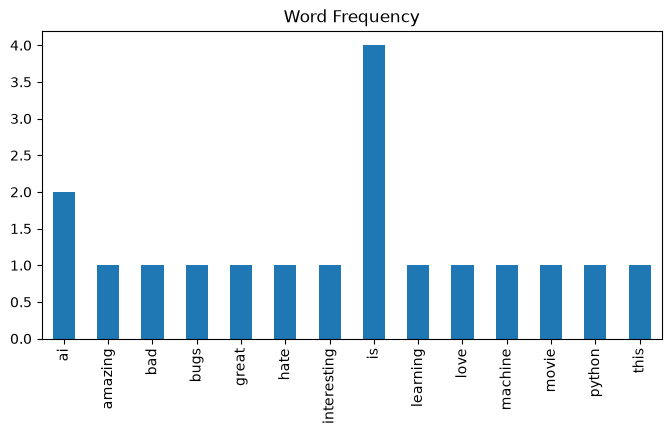

In [13]:
import matplotlib.pyplot as plt

word_counts = bow_df.sum()

plt.figure(figsize=(8,4))

word_counts.plot(kind="bar")

plt.title("Word Frequency")

plt.show()

## ✅ Advantages

- Very simple
- Easy to implement 
- Fast
- Works well for small datasets
- Good baseline model

## ❌ Disadvantages

Bag of Words only counts words.

It does not understand:

- word meaning
- grammar
- sentence order
- context

Example:

Dog bites man

Man bites dog

Both contain exactly the same words.

BoW treats them as almost identical.

It also gives equal importance to common words like:

the

is

a

These words usually carry very little information.

## ✅ Summary

Today I learned:

- Why Rule-Based Systems failed.
- How BoW converts text into numbers.
- How CountVectorizer works.
- How to train a Machine Learning model using BoW.
- Why BoW still has limitations.